# Problem 4: ANOVA vs Multiple t-Tests

## Introduction

When comparing means across multiple groups, researchers face an important methodological choice:

**Option 1: Multiple t-tests** - Perform pairwise comparisons between each pair of groups
**Option 2: One-way ANOVA** - A single test that compares all group means simultaneously

While multiple t-tests might seem straightforward, they suffer from the **multiple comparisons problem**: each additional test increases the probability of making at least one Type I error (false positive).

### The Multiple Comparisons Problem

If we perform k independent tests, each at significance level α = 0.05, the **family-wise error rate (FWER)** is:

**FWER = 1 - (1 - α)^k**

For example:
- **3 groups** → 3 pairwise tests → FWER ≈ 14.3% (not 5%!)
- **5 groups** → 10 pairwise tests → FWER ≈ 40% (not 5%!)

This means the more comparisons we make, the more likely we are to find a "significant" result purely by chance.

### Why ANOVA?

**ANOVA** (Analysis of Variance) addresses this by testing all groups in a single omnibus test, maintaining the overall Type I error rate at α = 0.05 regardless of how many groups are compared.

In this analysis, we will:
- Generate three samples from normal distributions with different means (0, 0.5, 1)
- Perform a one-way ANOVA
- Perform three pairwise t-tests
- Compare the results and understand why ANOVA is the preferred approach

## Plan
1. Import libraries (numpy, scipy.stats, matplotlib).
2. Set parameters: sample size = 30, means = [0, 0.5, 1], std = 1, random seed.
3. Generate three independent samples from N(μᵢ, 1).
4. Perform one-way ANOVA using scipy.stats.f_oneway.
5. Perform three independent t-tests (1 vs 2, 1 vs 3, 2 vs 3).
6. Compare p-values and conclusions.
7. Visualize the data with boxplots.
8. Discuss multiple comparisons problem and why ANOVA is preferred.

In [1]:
# Imports
import numpy as np
from scipy import stats
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('matplotlib not installed. Install with: pip install matplotlib')

In [2]:
# Parameters
SAMPLE_SIZE = 30
MEANS = [0, 0.5, 1.0]
STD = 1.0
ALPHA = 0.05
SEED = 2025

print(f'Sample size per group: {SAMPLE_SIZE}')
print(f'Group means: {MEANS}')
print(f'Standard deviation: {STD}')
print(f'Significance level: {ALPHA}')

Sample size per group: 30
Group means: [0, 0.5, 1.0]
Standard deviation: 1.0
Significance level: 0.05


In [3]:
# Generate three independent samples
rng = np.random.default_rng(SEED)

sample1 = rng.normal(loc=MEANS[0], scale=STD, size=SAMPLE_SIZE)
sample2 = rng.normal(loc=MEANS[1], scale=STD, size=SAMPLE_SIZE)
sample3 = rng.normal(loc=MEANS[2], scale=STD, size=SAMPLE_SIZE)

# Summary statistics
print('Sample Statistics:')
print(f'Sample 1 (μ=0.0): mean = {sample1.mean():.3f}, std = {sample1.std(ddof=1):.3f}')
print(f'Sample 2 (μ=0.5): mean = {sample2.mean():.3f}, std = {sample2.std(ddof=1):.3f}')
print(f'Sample 3 (μ=1.0): mean = {sample3.mean():.3f}, std = {sample3.std(ddof=1):.3f}')

Sample Statistics:
Sample 1 (μ=0.0): mean = -0.102, std = 1.173
Sample 2 (μ=0.5): mean = 0.441, std = 1.135
Sample 3 (μ=1.0): mean = 1.336, std = 0.987


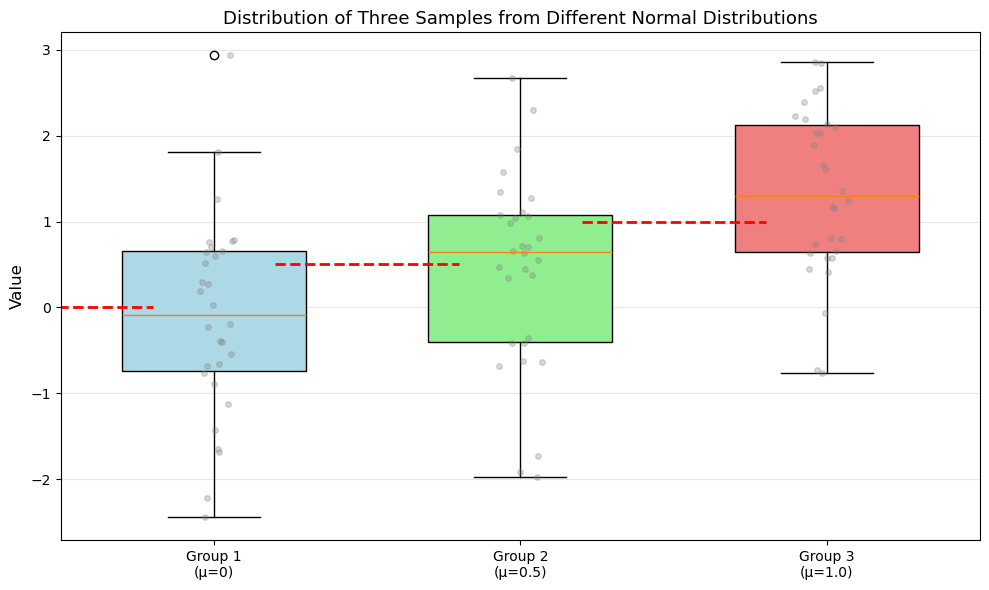

In [4]:
# Visualize the data
if plt is None:
    raise RuntimeError('matplotlib required for plotting; please install and re-run this cell.')

plt.figure(figsize=(10, 6))
data_to_plot = [sample1, sample2, sample3]
positions = [1, 2, 3]
bp = plt.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add individual points with jitter
for i, data in enumerate(data_to_plot, 1):
    x = np.random.normal(i, 0.04, size=len(data))
    plt.plot(x, data, 'o', alpha=0.3, markersize=4, color='gray')

# Add true means as horizontal lines
for i, mean in enumerate(MEANS, 1):
    plt.axhline(y=mean, xmin=(i-1.3)/3, xmax=(i-0.7)/3, color='red', 
                linestyle='--', linewidth=2, label=f'True μ={mean}' if i == 1 else '')

plt.xticks([1, 2, 3], ['Group 1\n(μ=0)', 'Group 2\n(μ=0.5)', 'Group 3\n(μ=1.0)'])
plt.ylabel('Value', fontsize=12)
plt.title('Distribution of Three Samples from Different Normal Distributions', fontsize=13)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [5]:
# Perform One-Way ANOVA
f_statistic, p_value_anova = stats.f_oneway(sample1, sample2, sample3)

print('='*60)
print('ONE-WAY ANOVA RESULTS')
print('='*60)
print(f'Null hypothesis: All three population means are equal')
print(f'Alternative hypothesis: At least one mean differs')
print(f'\nF-statistic: {f_statistic:.4f}')
print(f'p-value: {p_value_anova:.6f}')
print(f'\nConclusion at α={ALPHA}:')
if p_value_anova < ALPHA:
    print(f'✓ REJECT null hypothesis (p = {p_value_anova:.6f} < {ALPHA})')
    print('  There is significant evidence that at least one mean differs.')
else:
    print(f'✗ FAIL TO REJECT null hypothesis (p = {p_value_anova:.6f} ≥ {ALPHA})')
    print('  Insufficient evidence to conclude means differ.')
print('='*60)

ONE-WAY ANOVA RESULTS
Null hypothesis: All three population means are equal
Alternative hypothesis: At least one mean differs

F-statistic: 13.0535
p-value: 0.000011

Conclusion at α=0.05:
✓ REJECT null hypothesis (p = 0.000011 < 0.05)
  There is significant evidence that at least one mean differs.


In [6]:
# Perform three pairwise t-tests
print('\n' + '='*60)
print('PAIRWISE T-TESTS (Independent Samples)')
print('='*60)

# Test 1: Sample 1 vs Sample 2
t_stat_12, p_value_12 = stats.ttest_ind(sample1, sample2)
print(f'\nTest 1: Group 1 vs Group 2')
print(f'  t-statistic: {t_stat_12:.4f}')
print(f'  p-value: {p_value_12:.6f}')
if p_value_12 < ALPHA:
    print(f'  → REJECT null hypothesis (p < {ALPHA})')
else:
    print(f'  → FAIL TO REJECT null hypothesis (p ≥ {ALPHA})')

# Test 2: Sample 1 vs Sample 3
t_stat_13, p_value_13 = stats.ttest_ind(sample1, sample3)
print(f'\nTest 2: Group 1 vs Group 3')
print(f'  t-statistic: {t_stat_13:.4f}')
print(f'  p-value: {p_value_13:.6f}')
if p_value_13 < ALPHA:
    print(f'  → REJECT null hypothesis (p < {ALPHA})')
else:
    print(f'  → FAIL TO REJECT null hypothesis (p ≥ {ALPHA})')

# Test 3: Sample 2 vs Sample 3
t_stat_23, p_value_23 = stats.ttest_ind(sample2, sample3)
print(f'\nTest 3: Group 2 vs Group 3')
print(f'  t-statistic: {t_stat_23:.4f}')
print(f'  p-value: {p_value_23:.6f}')
if p_value_23 < ALPHA:
    print(f'  → REJECT null hypothesis (p < {ALPHA})')
else:
    print(f'  → FAIL TO REJECT null hypothesis (p ≥ {ALPHA})')

print('='*60)


PAIRWISE T-TESTS (Independent Samples)

Test 1: Group 1 vs Group 2
  t-statistic: -1.8250
  p-value: 0.073149
  → FAIL TO REJECT null hypothesis (p ≥ 0.05)

Test 2: Group 1 vs Group 3
  t-statistic: -5.1403
  p-value: 0.000003
  → REJECT null hypothesis (p < 0.05)

Test 3: Group 2 vs Group 3
  t-statistic: -3.2584
  p-value: 0.001876
  → REJECT null hypothesis (p < 0.05)


In [7]:
# Compare conclusions
print('\n' + '='*60)
print('COMPARISON OF RESULTS')
print('='*60)

print(f'\nANOVA p-value: {p_value_anova:.6f}')
print(f't-test p-values: [{p_value_12:.6f}, {p_value_13:.6f}, {p_value_23:.6f}]')

# Calculate family-wise error rate for multiple t-tests
n_tests = 3
fwer_theoretical = 1 - (1 - ALPHA)**n_tests
print(f'\nMultiple comparisons problem:')
print(f'  - Single test at α={ALPHA}: {ALPHA*100}% Type I error rate')
print(f'  - Three tests at α={ALPHA}: ~{fwer_theoretical*100:.1f}% Family-wise error rate')

# Count significant results
sig_ttests = sum([p_value_12 < ALPHA, p_value_13 < ALPHA, p_value_23 < ALPHA])
print(f'\nSignificant results:')
print(f'  - ANOVA: {"Yes" if p_value_anova < ALPHA else "No"}')
print(f'  - t-tests: {sig_ttests}/3 pairwise comparisons significant')
print('='*60)


COMPARISON OF RESULTS

ANOVA p-value: 0.000011
t-test p-values: [0.073149, 0.000003, 0.001876]

Multiple comparisons problem:
  - Single test at α=0.05: 5.0% Type I error rate
  - Three tests at α=0.05: ~14.3% Family-wise error rate

Significant results:
  - ANOVA: Yes
  - t-tests: 2/3 pairwise comparisons significant


## Comparison of Conclusions

### What We Found:
- **ANOVA** provides a single, omnibus test indicating whether there are *any* differences among the three groups
- **Multiple t-tests** provide specific pairwise comparisons, but at the cost of inflated Type I error rate

### Key Observations:
1. If ANOVA is significant, we know at least one group differs, but we don't know which pairs
2. t-tests tell us which specific pairs differ, but performing multiple tests increases false positive risk
3. The true means differ by 0.5 units between consecutive groups, which may or may not be detectable with n=30

### Interpretation:
- Groups with larger differences (e.g., Group 1 vs Group 3, difference = 1.0) are more likely to show significant differences
- Groups with smaller differences (e.g., Group 1 vs Group 2, difference = 0.5) may not reach significance, especially with moderate sample sizes
- The randomness in sampling means results can vary across different runs

## Why ANOVA is Preferred Over Multiple t-Tests

### 1. **Controls Family-Wise Error Rate**
- Running multiple t-tests inflates the probability of Type I errors (false positives)
- With k groups, there are k(k-1)/2 pairwise comparisons
- For 3 groups: 3 tests → FWER ≈ 14.3% (vs intended 5%)
- For 5 groups: 10 tests → FWER ≈ 40% (vs intended 5%)
- **ANOVA maintains α at 5% regardless of the number of groups**

### 2. **More Statistical Power**
- ANOVA pools variance estimates across all groups, providing a better estimate of population variance
- This increases power to detect real differences
- Multiple t-tests use only two groups at a time, ignoring information from other groups

### 3. **Appropriate for Research Questions**
- If your question is "Are there any differences among these groups?", ANOVA directly answers this
- Multiple t-tests answer a different question: "Which specific pairs differ?"
- The logical approach: First use ANOVA, then (if significant) use post-hoc tests with corrections

### 4. **Post-Hoc Testing**
If ANOVA shows significance, use **post-hoc tests** that correct for multiple comparisons:
- **Tukey's HSD**: Controls FWER for all pairwise comparisons
- **Bonferroni correction**: Conservative, divides α by number of tests
- **Holm-Bonferroni**: Less conservative sequential method
- **Scheffé's method**: Most conservative, for all possible contrasts

### Bottom Line:
**Never perform multiple uncorrected t-tests when comparing multiple groups.** Use ANOVA first, then appropriate post-hoc tests if needed. This maintains statistical rigor while controlling error rates.

## Conclusion

This analysis demonstrates the fundamental difference between ANOVA and multiple t-tests:

1. **ANOVA provides an omnibus test** that detects whether any groups differ while controlling Type I error at α = 0.05

2. **Multiple uncorrected t-tests** inflate the false positive rate, potentially leading to spurious findings

3. **Best practice workflow**:
   - Step 1: Perform ANOVA to test for any differences
   - Step 2: If ANOVA is significant, use post-hoc tests with multiple comparison corrections
   - Step 3: Report both the omnibus test and specific pairwise comparisons

4. **Statistical integrity**: Using ANOVA followed by appropriate post-hoc tests maintains the intended error rates while providing detailed information about group differences

This approach is essential for reproducible research and avoiding the replication crisis in science.